In [13]:
# %pip install -r requirements.txt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

import kmrf as kmrf

%matplotlib inline

In [14]:
classification_dir = 'original'  # Specify the classification directory here
asset_class_dir = 'us_equity'    # Specify the asset class directory here

In [15]:
# List available saved KMRF models for specified classification and asset class
saved_models_dir = Path(f'saved_models/KMRF/{classification_dir}_labels/{asset_class_dir}')

if saved_models_dir.exists():
    saved_models_list = list(saved_models_dir.glob('*.pkl'))

    if saved_models_list:
        saved_models_list = sorted(saved_models_list)
        print(f"Available saved models in '{saved_models_dir}':\n")
        for i, model_path in enumerate(saved_models_list):
            print(f" index = {i}: {model_path.name}")
    else:
        print(f"No saved models found in '{saved_models_dir}'. Train a model first!")

Available saved models in 'saved_models/KMRF/original_labels/us_equity':

 index = 0: KMRF_Consumer-Discretionary-Select-Sector-SPDR_20190101_boruta.pkl
 index = 1: KMRF_Consumer-Staples-Select-Sector-SPDR_20190101_boruta.pkl
 index = 2: KMRF_Energy-Select-Sector-SPDR_20190101_boruta.pkl
 index = 3: KMRF_Financial-Select-Sector-SPDR_20190101_boruta.pkl
 index = 4: KMRF_Health-Care-Select-Sector-SPDR_20190101_boruta.pkl
 index = 5: KMRF_Industrial-Select-Sector-SPDR_20190101_boruta.pkl
 index = 6: KMRF_Invesco-QQQ-Trust_20190101_boruta.pkl
 index = 7: KMRF_Materials-Select-Sector-SPDR_20190101_boruta.pkl
 index = 8: KMRF_SPDR-Dow-Jones-Industrial-Average-ETF_20190101_boruta.pkl
 index = 9: KMRF_SPDR-S&P-500-ETF_20190101_boruta.pkl
 index = 10: KMRF_Technology-Select-Sector-SPDR_20190101_boruta.pkl
 index = 11: KMRF_Utilities-Select-Sector-SPDR_20190101_boruta.pkl
 index = 12: KMRF_iShares-Micro-Cap-ETF_20190101_boruta.pkl
 index = 13: KMRF_iShares-Russell-2000-ETF_20190101_boruta.pkl
 i

In [16]:
model_index = 9
kmrf_model = kmrf.KMRF.load_model(saved_models_list[model_index])
display(kmrf_model)
print('Dropped Features during Boruta Selection:')
print(set(kmrf_model.features.columns).union(set(kmrf_model.features.columns)) - set(kmrf_model.selected_features))

KMRF model initialized
  Asset: SPDR S&P 500 ETF
  Asset class: us_equity
  Classification type: original
  End date: 20190101
  Using pre-computed features: True
  Data path: data/ready/us_equity.csv
  KAMA+MSR model directory: saved_models/KAMA_MSR/us_equity/20190101
  Validation period: 2019-02-01 00:00:00 to 2021-12-31 00:00:00
  Test start: 2022-02-01 00:00:00
  Random seed: 1010


KMRF('us_equity, SPDR S&P 500 ETF')
Raw OHLC Data (8242, 4): 1993-01-29 to 2025-10-24
Technical Features (8242, 95): 1993-01-29 to 2025-10-24
Macro Features (8242, 28): 1993-01-29 to 2025-10-24
Train (5789, 110): 1996-01-03 to 2018-12-31
Val (736, 110): 2019-02-01 to 2021-12-31
Test (937, 110): 2022-02-01 to 2025-10-24

Dropped Features during Boruta Selection:
{'open_to_close_lag1d', 'close_lag1d', 'log_ret_intraday_lag1d', 'vwap_lag1d', 'tsfresh_volume_lag1d__length', 'high_lag1d', 'open', 'tsfresh_close_lag1d__length', 'low_lag1d', 'open_lag1d'}



Generating predictions...
  Input shape: (736, 110)
  Using pre-selected features: 110
✓ Generated probability predictions: (736, 4)

PREDICTION SUMMARY FOR SPDR S&P 500 ETF
Test Period: 2019-02-01 to 2021-12-31
Total Trading Days: 736

Price Performance:
  Start Price (open on 2019-02-01): $270.15
  End Price (close on 2021-12-31): $474.96
  Buy and Hold Return: 75.81%

Regime Prediction Statistics:
  LV Bullish: 570 days ( 77.4%) | Avg Prob: 0.647
  LV Bearish:  63 days (  8.6%) | Avg Prob: 0.129
  HV Bullish:  56 days (  7.6%) | Avg Prob: 0.156
  HV Bearish:  47 days (  6.4%) | Avg Prob: 0.067

High Confidence Predictions (>70%): 447 days (60.7%)


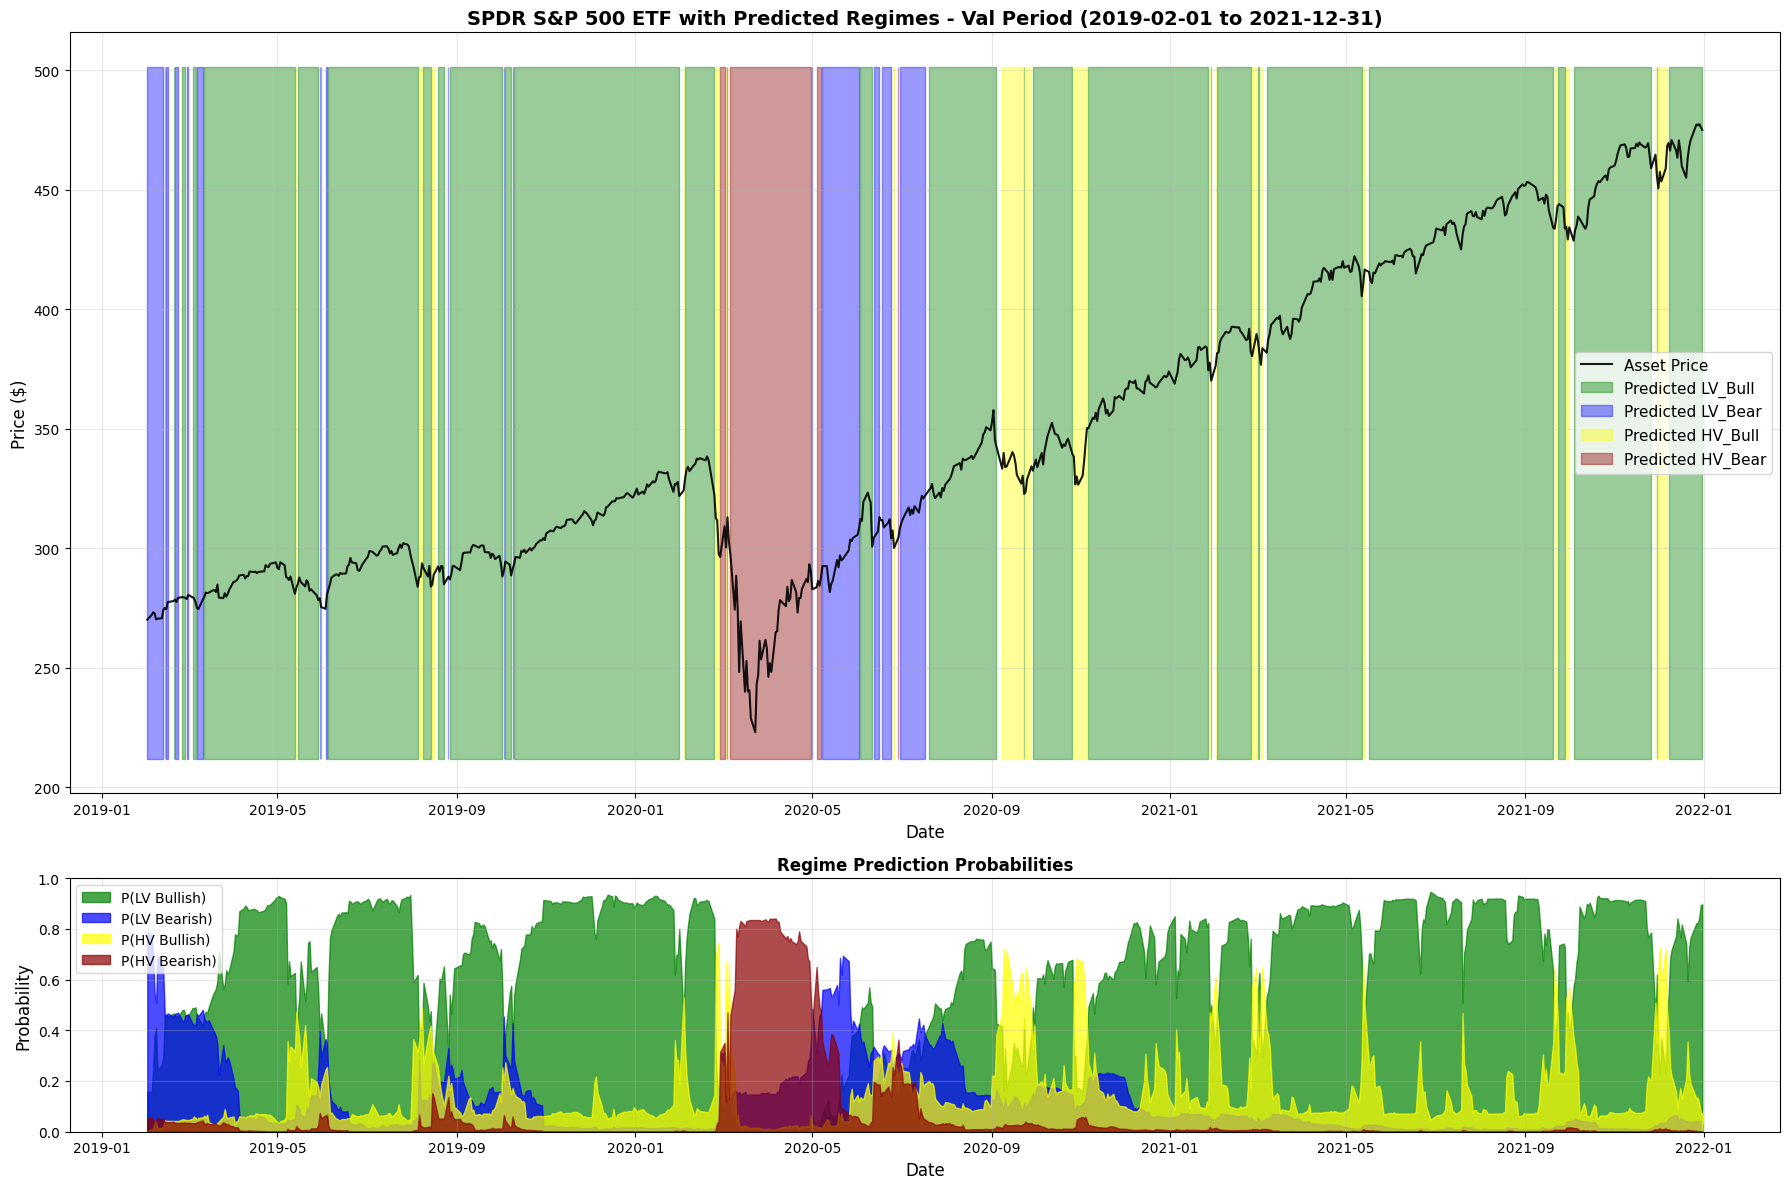

In [17]:
kmrf_model.predict(test_or_val='val')
kmrf_model.viz_predictions(test_or_val='val')


Generating predictions...
  Input shape: (937, 110)
  Using pre-selected features: 110
✓ Generated probability predictions: (937, 4)

PREDICTION SUMMARY FOR SPDR S&P 500 ETF
Test Period: 2022-02-01 to 2025-10-24
Total Trading Days: 937

Price Performance:
  Start Price (open on 2022-02-01): $450.68
  End Price (close on 2025-10-24): $677.25
  Buy and Hold Return: 50.27%

Regime Prediction Statistics:
  LV Bullish: 613 days ( 65.4%) | Avg Prob: 0.559
  LV Bearish: 235 days ( 25.1%) | Avg Prob: 0.234
  HV Bullish:  25 days (  2.7%) | Avg Prob: 0.118
  HV Bearish:  64 days (  6.8%) | Avg Prob: 0.089

High Confidence Predictions (>70%): 552 days (58.9%)


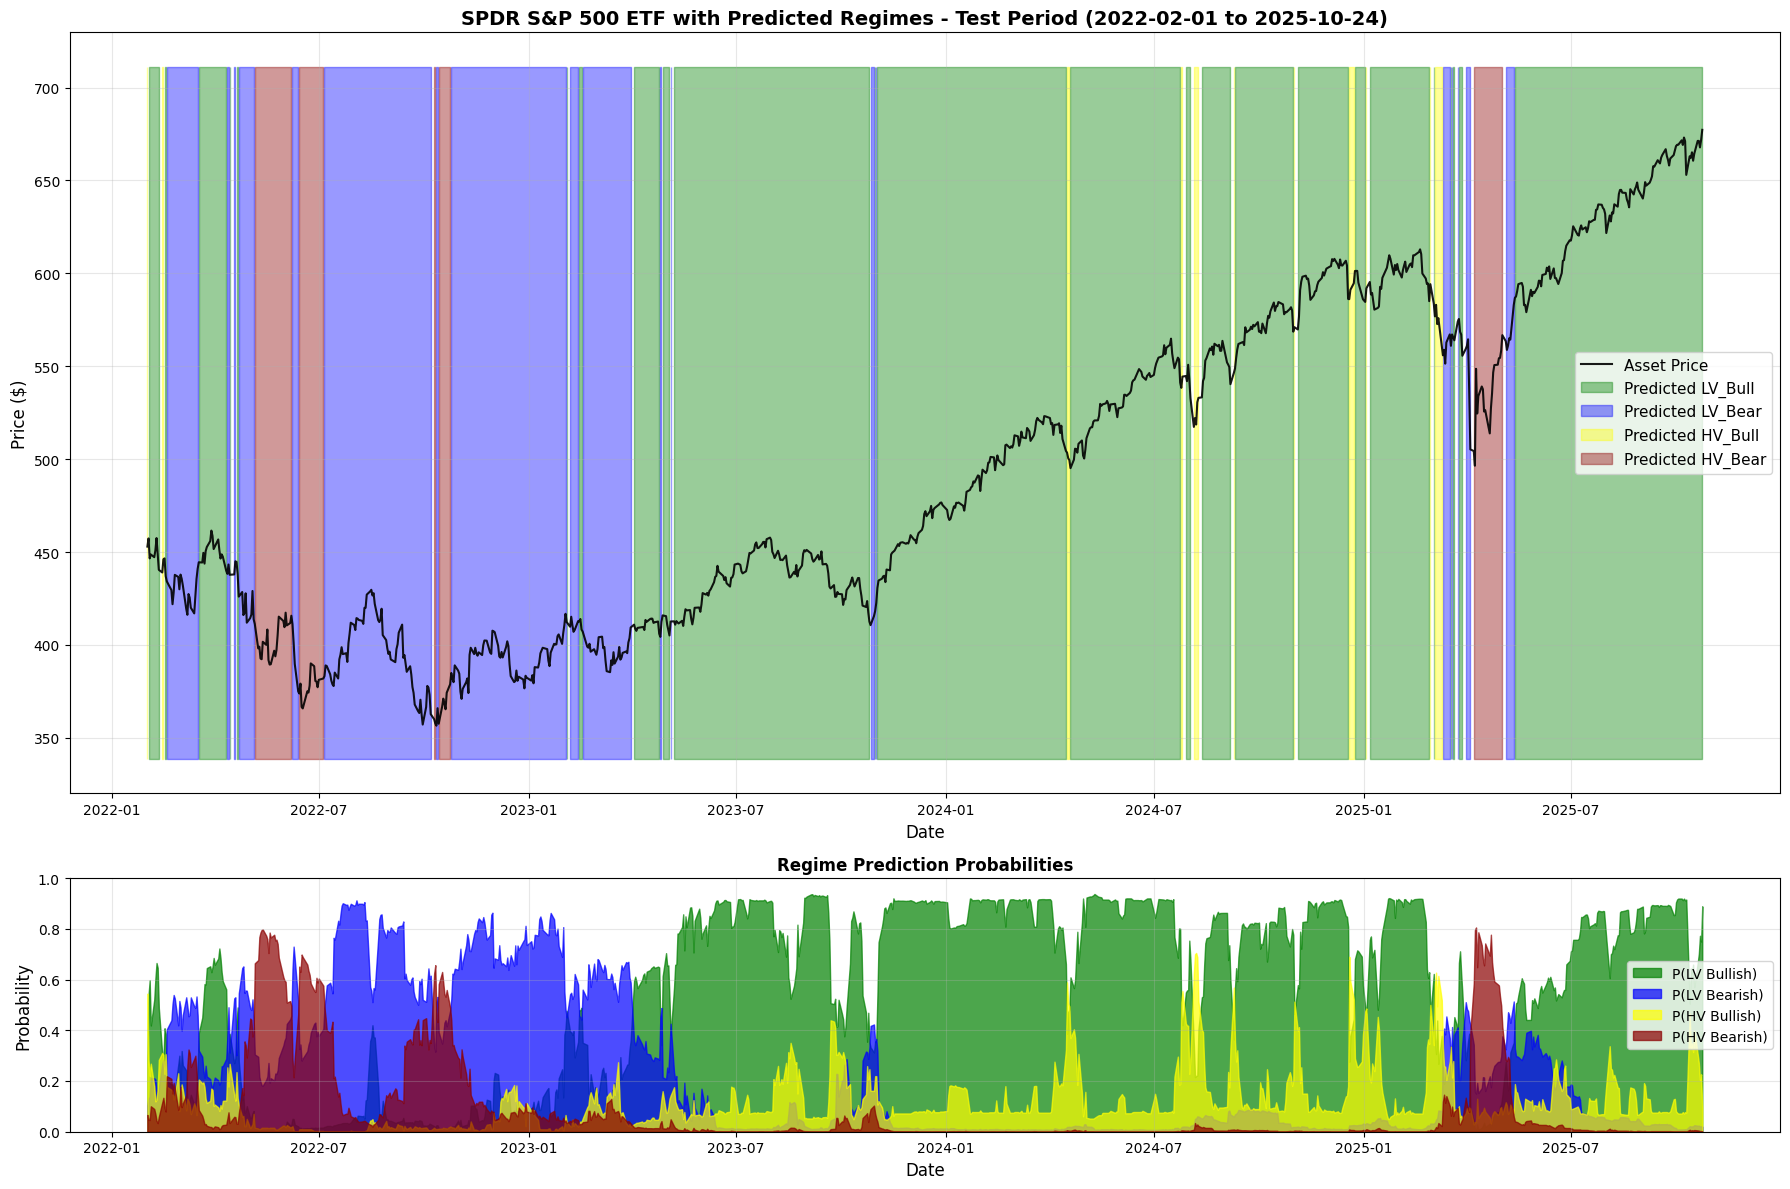

In [18]:
kmrf_model.predict(test_or_val='test')
kmrf_model.viz_predictions(test_or_val='test')